# Continuous 3D metrics -- cross-model comparison

Analysis of `continuous_3d_metrics.xlsx`, produced by `Continuous_3D_metrics.py`
(same folder's parent) from the `Segmentation_conditional` / `Segmentation_OCTAID` /
`Segmentation_OCTAIDlite` / `Segmentation_UNET3D` prediction volumes in
`Test_set_Performance`.

Two output files currently exist in `../output/`: `continuous_3d_metrics.xlsx` (latest,
used below) and `continuous_3d_metrics_06082026.xlsx` (an earlier run). Change
`EXCEL_PATH` below if you want the other one.

Every figure uses a **fixed color per model** (never re-cycled) so the same model is
always the same color across the whole notebook.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

EXCEL_PATH = Path("../output/continuous_3d_metrics_07_08_2026.xlsx")

overall  = pd.read_excel(EXCEL_PATH, sheet_name="Overall_Per_Model")
per_pb   = pd.read_excel(EXCEL_PATH, sheet_name="Per_Pullback_Summary")
lesions  = pd.read_excel(EXCEL_PATH, sheet_name="TCFA_Lesions")
frames   = pd.read_excel(EXCEL_PATH, sheet_name="Frame_Level")

print(f"{EXCEL_PATH.name}: {per_pb['pullback'].nunique()} pullbacks, "
      f"{per_pb['model'].nunique()} models: {sorted(per_pb['model'].unique())}")

continuous_3d_metrics_07_08_2026.xlsx: 30 pullbacks, 4 models: ['ConditionalINR', 'OCTAID', 'OCTAIDlite', 'UNET3D']


In [3]:
# ---- Fixed categorical color per model (validated 4-hue order, never re-cycled) ----
MODEL_COLORS = {
    "ConditionalINR": "#2a78d6",  # blue
    "OCTAID":         "#eb6834",  # orange
    "OCTAIDlite":     "#1baf7a",  # aqua
    "UNET3D":         "#eda100",  # yellow
}
MODEL_ORDER = list(MODEL_COLORS)

INK        = "#0b0b0b"
INK_MUTED  = "#898781"
GRIDLINE   = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "axes.edgecolor":   GRIDLINE,
    "axes.grid":        True,
    "grid.color":       GRIDLINE,
    "grid.linewidth":   0.8,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "text.color":       INK,
    "axes.labelcolor":  INK,
    "xtick.color":      INK_MUTED,
    "ytick.color":      INK_MUTED,
    "font.size": 10,
})

def model_color(m):
    return MODEL_COLORS.get(m, "#898781")

## 1. Overall comparison (mean over all pullbacks, per model)

FCT and lipid arc means, plus TCFA lesion count/length -- the headline numbers from
`Overall_Per_Model`. Each subplot is one measure (never mixed on a shared/dual axis);
bars share the same fixed model colors throughout.

C:\Users\z923198\AppData\Local\Temp\ipykernel_24904\997797680.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ov.index, rotation=20, ha="right")
C:\Users\z923198\AppData\Local\Temp\ipykernel_24904\997797680.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ov.index, rotation=20, ha="right")
C:\Users\z923198\AppData\Local\Temp\ipykernel_24904\997797680.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ov.index, rotation=20, ha="right")
C:\Users\z923198\AppData\Local\Temp\ipykernel_24904\997797680.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ov.index, rotation=20, 

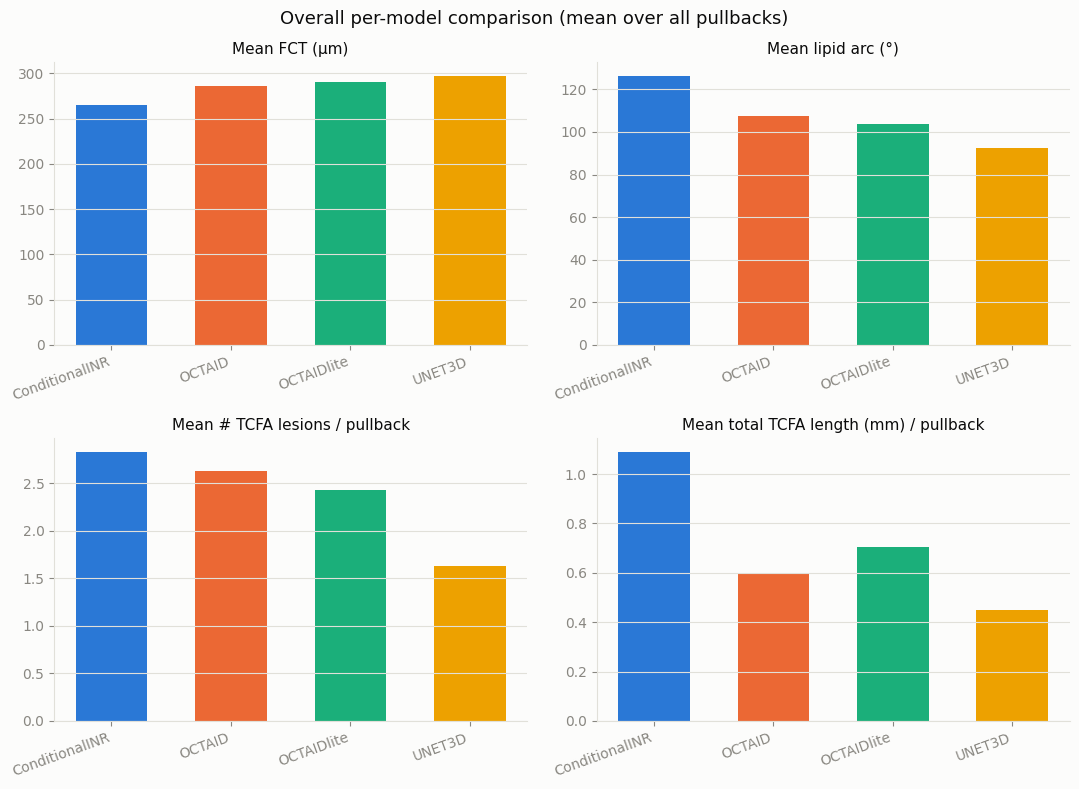

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
metrics = [
    ("Mean_FCT_um",           "Mean FCT (\u00b5m)"),
    ("Mean_Lipid_Arc_deg",    "Mean lipid arc (\u00b0)"),
    ("n_TCFA_lesions",        "Mean # TCFA lesions / pullback"),
    ("total_TCFA_length_mm",  "Mean total TCFA length (mm) / pullback"),
]
ov = overall.set_index("model").reindex(MODEL_ORDER)

for ax, (col, title) in zip(axes.ravel(), metrics):
    colors = [model_color(m) for m in ov.index]
    ax.bar(ov.index, ov[col], color=colors, width=0.6)
    ax.set_title(title, color=INK, fontsize=11)
    ax.set_xticklabels(ov.index, rotation=20, ha="right")
    ax.grid(axis="x", visible=False)

fig.suptitle("Overall per-model comparison (mean over all pullbacks)", fontsize=13, color=INK)
fig.tight_layout()
plt.show()

## 2. Lipid arc per pullback, all models

One dot+line per model across every pullback (`Per_Pullback_Summary.Mean_Lipid_Arc_deg`).
Pullbacks are sorted by the **cross-model average** so the overall trend reads left-to-right
and any single model's outliers are easy to spot against the others.

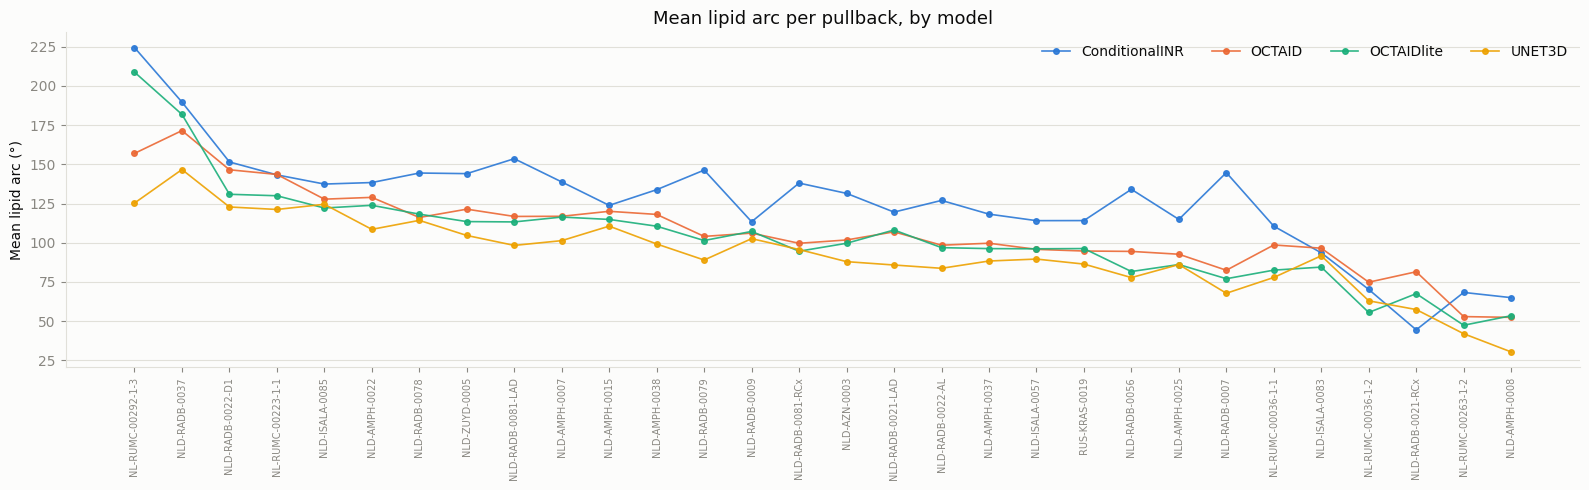

In [5]:
pivot_arc = per_pb.pivot(index="pullback", columns="model", values="Mean_Lipid_Arc_deg")
pivot_arc = pivot_arc[MODEL_ORDER]
order = pivot_arc.mean(axis=1).sort_values(ascending=False).index
pivot_arc = pivot_arc.loc[order]

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(pivot_arc))
for m in MODEL_ORDER:
    ax.plot(x, pivot_arc[m], marker="o", markersize=4, linewidth=1.2,
            color=model_color(m), label=m, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(pivot_arc.index, rotation=90, fontsize=7)
ax.set_ylabel("Mean lipid arc (\u00b0)")
ax.set_title("Mean lipid arc per pullback, by model", fontsize=13, color=INK)
ax.legend(frameon=False, ncol=4, loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 3. TCFA lesions per pullback, all models

Same layout as above, for `n_TCFA_lesions` (count of TCFA-positive runs per pullback --
`--tcfa_min_consecutive_frames` was left at 1, so this includes single-frame runs too;
see `TCFA_Lesions.meets_min_length` if you want to apply a stricter continuity cutoff
post-hoc without rerunning).

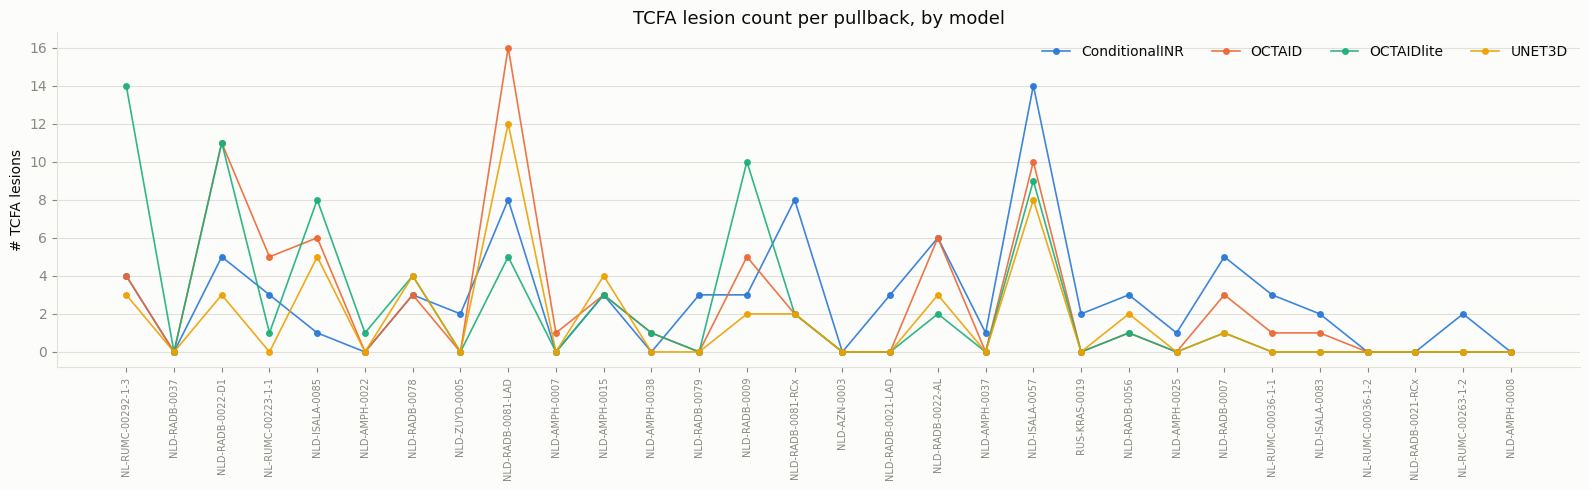

In [6]:
pivot_tcfa = per_pb.pivot(index="pullback", columns="model", values="n_TCFA_lesions")
pivot_tcfa = pivot_tcfa[MODEL_ORDER].loc[order]  # same pullback order as Figure 2

fig, ax = plt.subplots(figsize=(16, 5))
for m in MODEL_ORDER:
    ax.plot(x, pivot_tcfa[m], marker="o", markersize=4, linewidth=1.2,
            color=model_color(m), label=m, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(pivot_tcfa.index, rotation=90, fontsize=7)
ax.set_ylabel("# TCFA lesions")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title("TCFA lesion count per pullback, by model", fontsize=13, color=INK)
ax.legend(frameon=False, ncol=4, loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 4. TCFA concordance heatmap

Where do models actually agree on *which* pullbacks are TCFA-positive, not just the
aggregate count? Sequential single-hue (magnitude, not identity) -- darker = more lesions
detected in that pullback by that model. A pullback with a dark cell in one column and a
blank column next to it is a genuine model disagreement worth a closer look (e.g. via
Figure 6 below).

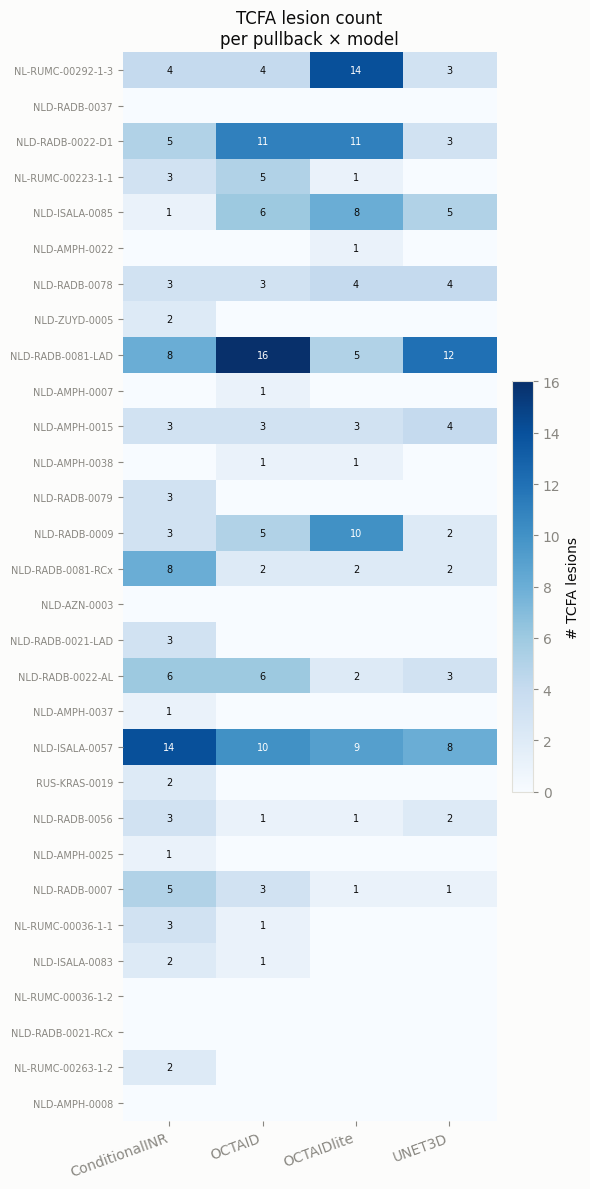

In [7]:
pivot_heat = pivot_tcfa.copy()  # reuse the same pullback order

fig, ax = plt.subplots(figsize=(6, 12))
im = ax.imshow(pivot_heat.values, aspect="auto", cmap="Blues", vmin=0)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, rotation=20, ha="right")
ax.set_yticks(range(len(pivot_heat)))
ax.set_yticklabels(pivot_heat.index, fontsize=7)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(pivot_heat.shape[0]):
    for j in range(pivot_heat.shape[1]):
        v = pivot_heat.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center",
                    fontsize=7, color="white" if v > pivot_heat.values.max() / 2 else INK)

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
cbar.set_label("# TCFA lesions")
ax.set_title("TCFA lesion count\nper pullback \u00d7 model", fontsize=12, color=INK)
fig.tight_layout()
plt.show()

## 5. Frame-level curves for the pullback with the most TCFA signal

Picks the pullback with the highest summed `total_TCFA_length_mm` across all 4 models,
then plots FCT and lipid arc **per frame** (not just the per-pullback mean) so you can see
whether the models track the same underlying curve shape or diverge/get noisy -- the
direct way to tell "real disagreement" from "one model's curve is jagged."

Frames excluded via the exclusion excel (guiding catheter / artifact, `Inclusion == 0`)
are left as gaps (NaN), not connected across.

Example pullback: NLD-ISALA-0057 (summed total_TCFA_length_mm across models = 17.50 mm)


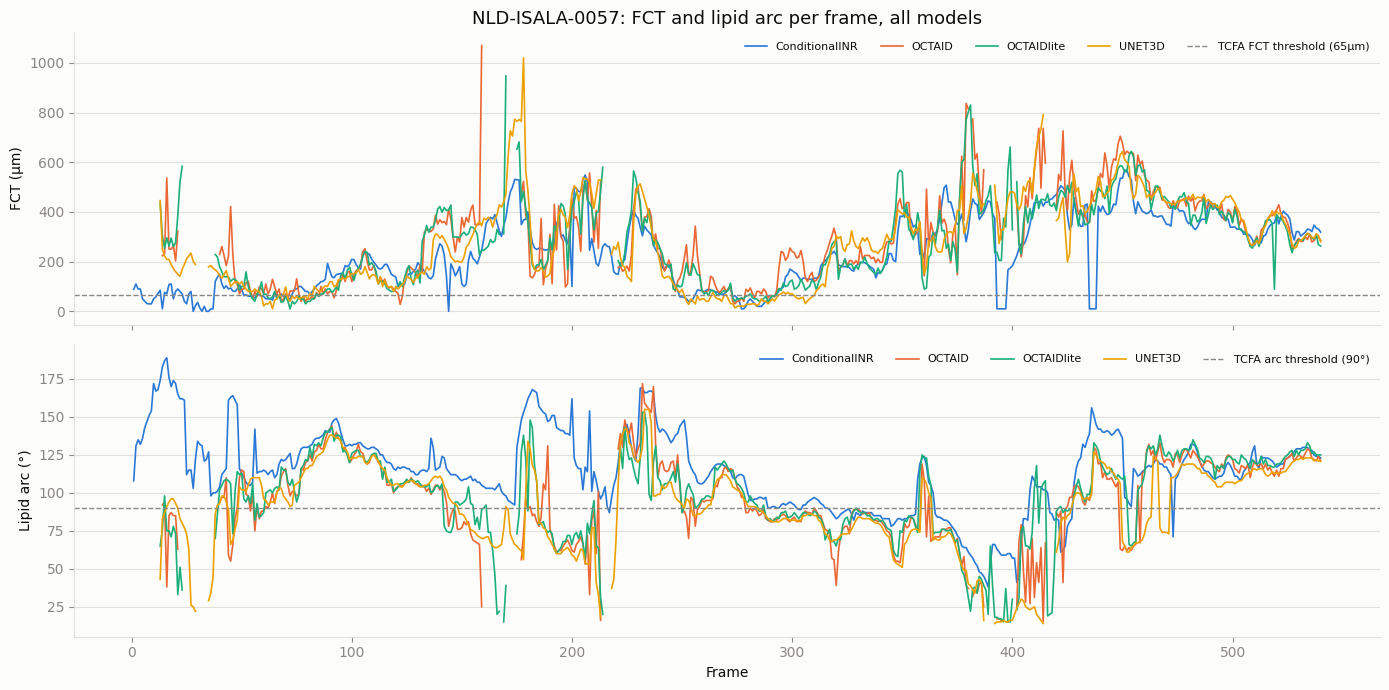

In [8]:
totals_by_pb = per_pb.groupby("pullback")["total_TCFA_length_mm"].sum().sort_values(ascending=False)
example_pid = totals_by_pb.index[0]
print(f"Example pullback: {example_pid} (summed total_TCFA_length_mm across models = "
      f"{totals_by_pb.iloc[0]:.2f} mm)")

sub = frames[frames["pullback"] == example_pid].copy()
sub.loc[sub["Inclusion"] == 0, ["FCT_um", "Lipid_Arc_deg"]] = np.nan

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for m in MODEL_ORDER:
    s = sub[sub["model"] == m].sort_values("frame_1based")
    axes[0].plot(s["frame_1based"], s["FCT_um"], color=model_color(m), label=m, linewidth=1.2)
    axes[1].plot(s["frame_1based"], s["Lipid_Arc_deg"], color=model_color(m), label=m, linewidth=1.2)

axes[0].axhline(65, color=INK_MUTED, linestyle="--", linewidth=1, label="TCFA FCT threshold (65\u00b5m)")
axes[1].axhline(90, color=INK_MUTED, linestyle="--", linewidth=1, label="TCFA arc threshold (90\u00b0)")
axes[0].set_ylabel("FCT (\u00b5m)")
axes[1].set_ylabel("Lipid arc (\u00b0)")
axes[1].set_xlabel("Frame")
axes[0].set_title(f"{example_pid}: FCT and lipid arc per frame, all models", fontsize=13, color=INK)
for ax in axes:
    ax.legend(frameon=False, ncol=5, fontsize=8)
    ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 6. Per-class mean area, all models

`Mean_Area_<class>_mm2` from `Overall_Per_Model`, one group of bars per class. Useful for
spotting systematic over/under-segmentation of a specific class by one model relative to
the others (e.g. the lipid-oversensitivity question this project has been tracking) rather
than relying on a single aggregate Dice-style number.

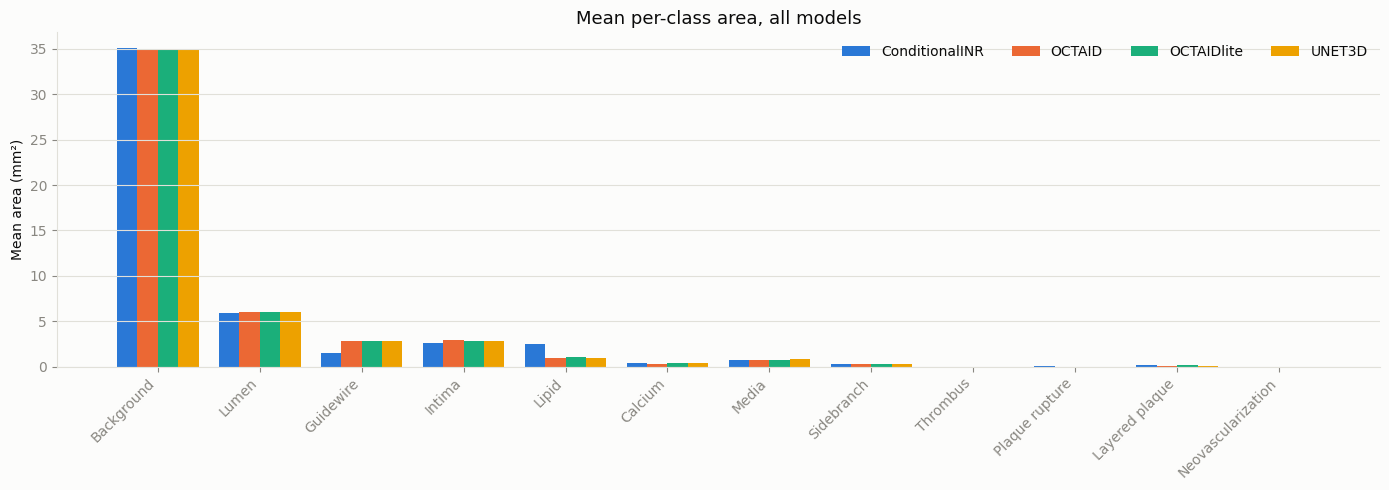

In [9]:
area_cols = [c for c in overall.columns if c.startswith("Mean_Area_")]
class_names = [c.replace("Mean_Area_", "").replace("_mm2", "") for c in area_cols]

area_long = overall.set_index("model")[area_cols].reindex(MODEL_ORDER)
area_long.columns = class_names

fig, ax = plt.subplots(figsize=(14, 5))
n_classes = len(class_names)
n_models = len(MODEL_ORDER)
bar_w = 0.8 / n_models
x = np.arange(n_classes)

for i, m in enumerate(MODEL_ORDER):
    ax.bar(x + i * bar_w, area_long.loc[m], width=bar_w, color=model_color(m), label=m)

ax.set_xticks(x + bar_w * (n_models - 1) / 2)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylabel("Mean area (mm\u00b2)")
ax.set_title("Mean per-class area, all models", fontsize=13, color=INK)
ax.legend(frameon=False, ncol=4)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 7. Model agreement: ConditionalINR vs. OCTAID (per-pullback means)

Scatter of per-pullback `Mean_Lipid_Arc_deg` and `Mean_FCT_um`, one model against another,
with the diagonal marking perfect agreement -- a systematic offset from the diagonal (bias)
reads differently from scatter around it (noise). Swap `MODEL_A`/`MODEL_B` for a different
pair.

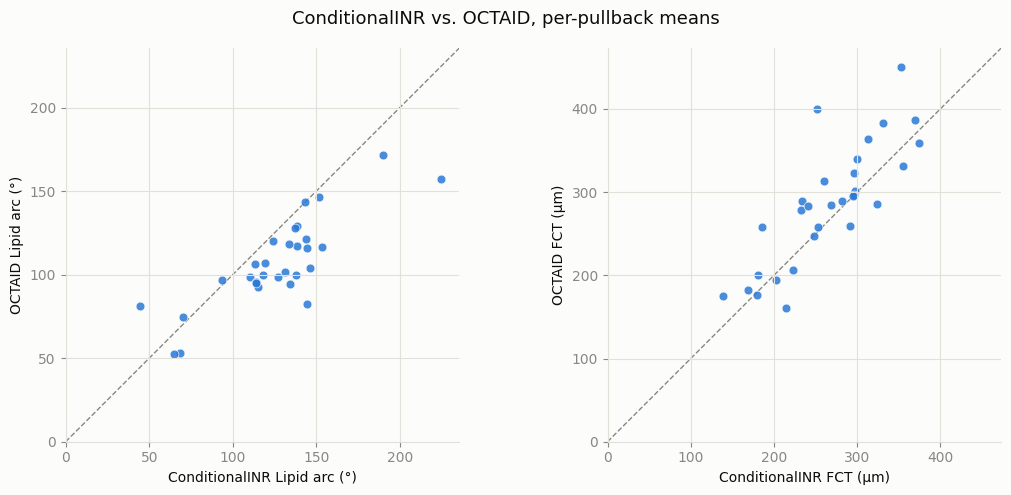

In [10]:
MODEL_A, MODEL_B = "ConditionalINR", "OCTAID"

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (col, label) in zip(axes, [("Mean_Lipid_Arc_deg", "Lipid arc (\u00b0)"),
                                     ("Mean_FCT_um", "FCT (\u00b5m)")]):
    wide = per_pb.pivot(index="pullback", columns="model", values=col)
    a, b = wide[MODEL_A], wide[MODEL_B]
    lim = [0, max(a.max(), b.max()) * 1.05]
    ax.plot(lim, lim, color=INK_MUTED, linestyle="--", linewidth=1, zorder=0)
    ax.scatter(a, b, color=model_color(MODEL_A), edgecolor="white", linewidth=0.5, s=40, alpha=0.85)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"{MODEL_A} {label}")
    ax.set_ylabel(f"{MODEL_B} {label}")
    ax.set_aspect("equal")

fig.suptitle(f"{MODEL_A} vs. {MODEL_B}, per-pullback means", fontsize=13, color=INK)
fig.tight_layout()
plt.show()

## 8. Comparing per-class area across all 30 pullbacks, properly paired

The same 30 pullbacks were predicted by all 4 models -- this is a **paired /
repeated-measures** design, not 4 independent samples. Two consequences:

- Frames are aggregated to one value per pullback first (`Mean_Area_<class>_mm2`,
  already computed), *then* compared across pullbacks -- pooling every frame from
  every pullback directly would let longer pullbacks dominate the result.
- Models are compared with **paired** methods (Friedman + pairwise Wilcoxon
  signed-rank) rather than treating each model's 30 values as unrelated groups,
  since e.g. `NLD-AMPH-0007`'s ConditionalINR/OCTAID/OCTAIDlite/UNET3D values are
  the same underlying vessel, not independent observations.

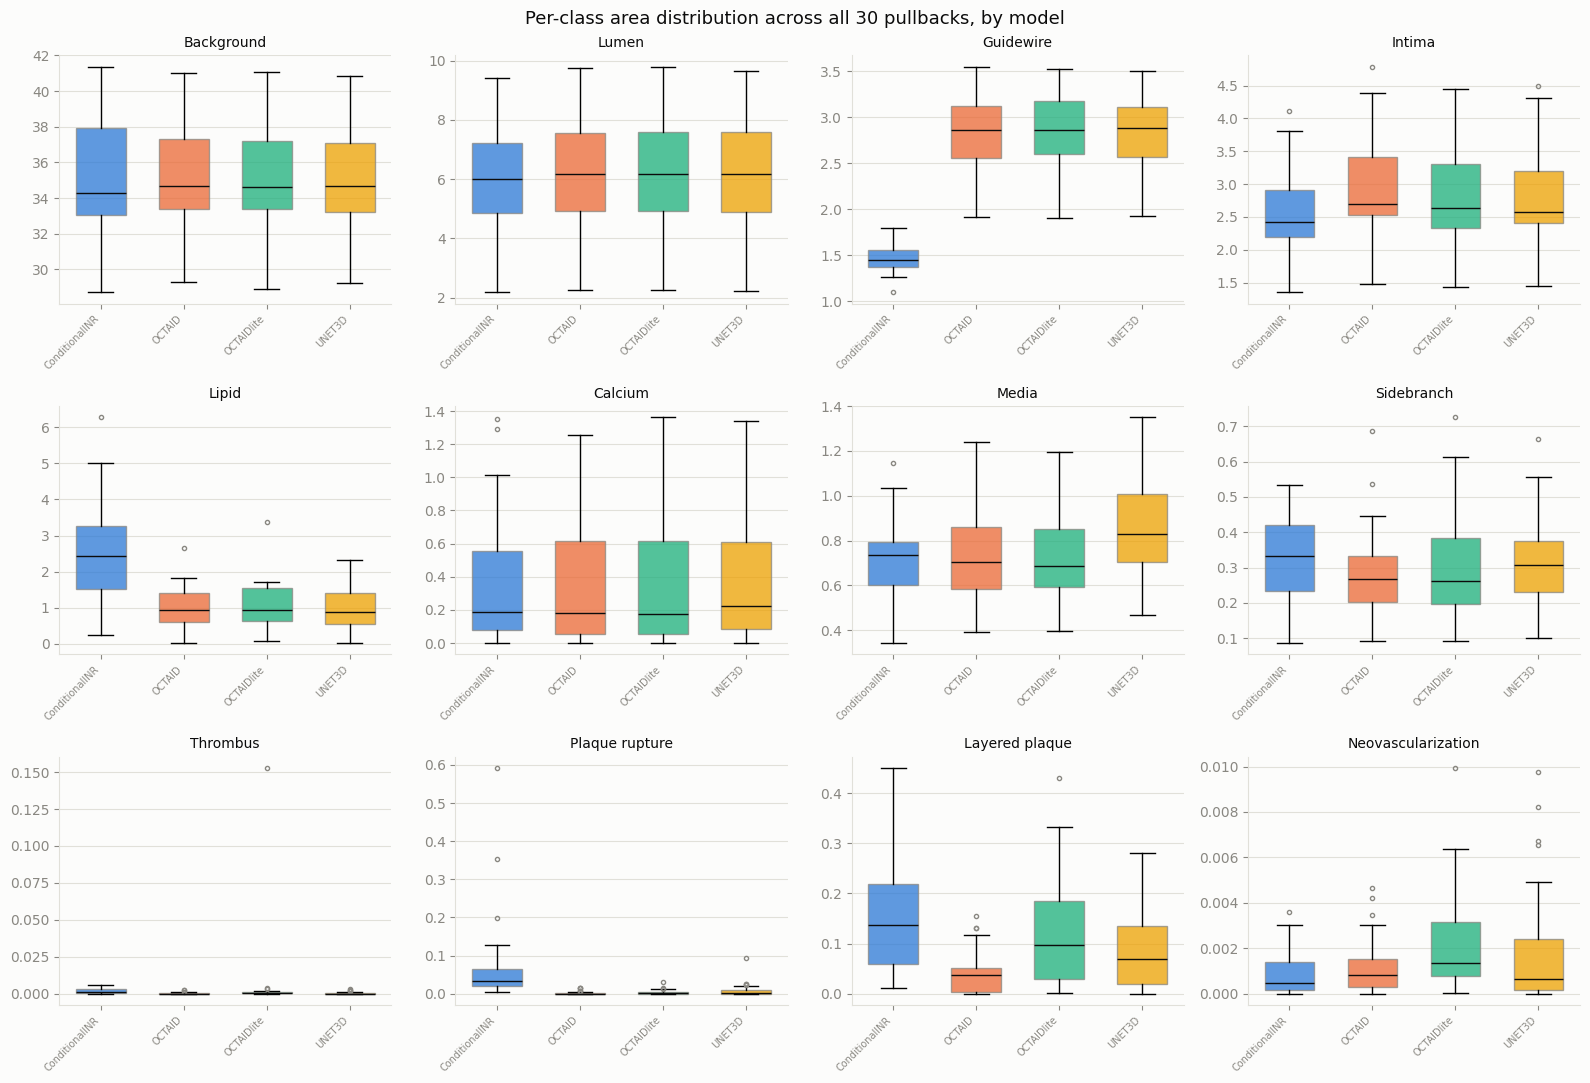

In [11]:
# ---- 8a. Marginal distribution per class (boxplot across all 30 pullbacks) ----
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, cls in zip(axes.ravel(), class_names):
    col = f"Mean_Area_{cls}_mm2"
    data = [per_pb.loc[per_pb["model"] == m, col].dropna().values for m in MODEL_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=True,
                     flierprops=dict(markersize=3, markeredgecolor=INK_MUTED))
    for patch, m in zip(bp["boxes"], MODEL_ORDER):
        patch.set_facecolor(model_color(m))
        patch.set_alpha(0.75)
        patch.set_edgecolor(INK_MUTED)
    for median in bp["medians"]:
        median.set_color(INK)
    ax.set_xticks(range(1, len(MODEL_ORDER) + 1))
    ax.set_xticklabels(MODEL_ORDER, rotation=45, ha="right", fontsize=7)
    ax.set_title(cls, fontsize=10, color=INK)
    ax.grid(axis="x", visible=False)

fig.suptitle("Per-class area distribution across all 30 pullbacks, by model", fontsize=13, color=INK)
fig.tight_layout()
plt.show()

### 8b. Is the difference real? Friedman test + paired Wilcoxon per class

`friedman_p` tests whether the 4 models differ *at all* for that class (omnibus).
The six pairwise columns are Wilcoxon signed-rank p-values, **Holm-corrected**
across the 6 comparisons per class (so the correction doesn't get stricter just
because more classes are shown). Cells below 0.05 are highlighted -- read the
omnibus column first; a pairwise cell only matters if the omnibus for that row is
also significant.

In [12]:
from itertools import combinations

from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

pairs = list(combinations(MODEL_ORDER, 2))
rows = []
for cls in class_names:
    col = f"Mean_Area_{cls}_mm2"
    wide = per_pb.pivot(index="pullback", columns="model", values=col)[MODEL_ORDER].dropna()

    _, p_omnibus = friedmanchisquare(*[wide[m] for m in MODEL_ORDER])

    raw_pvals = [wilcoxon(wide[a], wide[b]).pvalue for a, b in pairs]
    _, p_corrected, _, _ = multipletests(raw_pvals, method="holm")

    row = {"class": cls, "n_pullbacks": len(wide), "friedman_p": p_omnibus}
    row.update({f"{a} vs {b}": p for (a, b), p in zip(pairs, p_corrected)})
    rows.append(row)

stats_df = pd.DataFrame(rows).set_index("class")

def highlight_sig(v):
    if isinstance(v, float) and v < 0.05:
        return "background-color: #fbe3e3; color: #9a1c1c; font-weight: bold"
    return ""

stats_df.style.format({c: "{:.4f}" for c in stats_df.columns if c != "n_pullbacks"}) \
    .applymap(highlight_sig, subset=[c for c in stats_df.columns if c not in ("n_pullbacks",)])

C:\Users\z923198\AppData\Local\Temp\ipykernel_24904\1754458770.py:29: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_sig, subset=[c for c in stats_df.columns if c not in ("n_pullbacks",)])


,n_pullbacks,friedman_p,ConditionalINR vs OCTAID,ConditionalINR vs OCTAIDlite,ConditionalINR vs UNET3D,OCTAID vs OCTAIDlite,OCTAID vs UNET3D,OCTAIDlite vs UNET3D
class,,,,,,,,
Background,30,0.0000,0.3012,0.3012,0.0884,0.9354,0.0001,0.0128
Lumen,30,0.0001,0.0001,0.0009,0.0029,0.5028,0.0464,0.0464
Guidewire,30,0.0000,0.0000,0.0000,0.0000,1.0000,0.5118,1.0000
Intima,30,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8078
Lipid,30,0.0000,0.0000,0.0000,0.0000,0.6162,0.6162,0.6162
Calcium,30,0.0000,0.4738,0.4738,0.0119,0.8872,0.0000,0.0000
Media,30,0.0000,0.8799,0.9838,0.0000,0.0186,0.0000,0.0000
Sidebranch,30,0.0006,0.7088,0.7088,0.7088,0.7088,0.0000,0.0052
Thrombus,30,0.0000,0.0007,0.0810,0.0018,0.0000,0.7731,0.0015


### 8c. Full paired detail for one class

Every pullback as a light connecting line across the 4 models, colored dots on
top -- shows both the paired structure (which the boxplots above discard) and
the overall shift. Change `CLASS_TO_INSPECT` to look at any other class the
table above flags as significant.

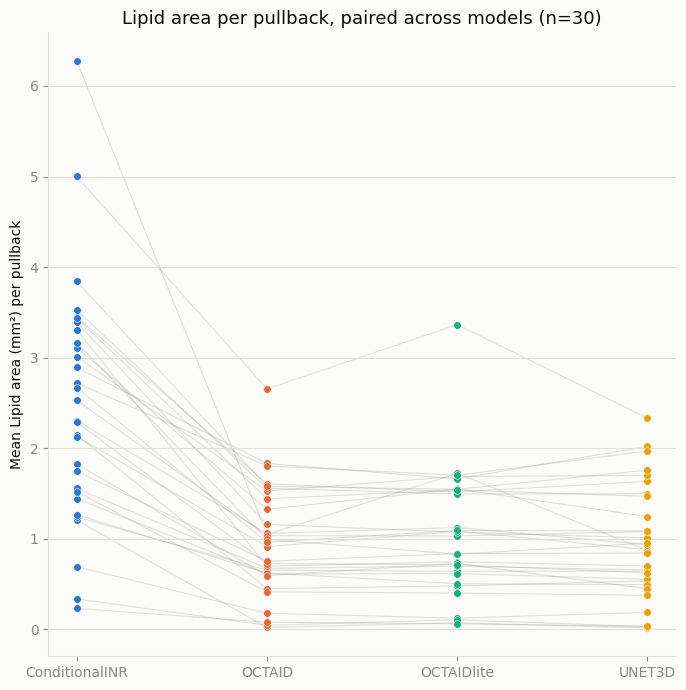

In [13]:
CLASS_TO_INSPECT = "Lipid"

col = f"Mean_Area_{CLASS_TO_INSPECT}_mm2"
wide = per_pb.pivot(index="pullback", columns="model", values=col)[MODEL_ORDER].dropna()

fig, ax = plt.subplots(figsize=(7, 7))
x_positions = np.arange(len(MODEL_ORDER))
for _, row in wide.iterrows():
    ax.plot(x_positions, row.values, color=INK_MUTED, alpha=0.25, linewidth=0.8, zorder=1)
for i, m in enumerate(MODEL_ORDER):
    ax.scatter(np.full(len(wide), i), wide[m], color=model_color(m), s=30,
               zorder=2, edgecolor="white", linewidth=0.4)

ax.set_xticks(x_positions)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel(f"Mean {CLASS_TO_INSPECT} area (mm\u00b2) per pullback")
ax.set_title(f"{CLASS_TO_INSPECT} area per pullback, paired across models "
             f"(n={len(wide)})", fontsize=13, color=INK)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()